In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
from skimage.feature import hog
from skimage import exposure
import pandas as pd
import os

In [2]:
print("Diretório atual:", os.getcwd())
print("Arquivos na pasta principal:", os.listdir())

Diretório atual: c:\Users\55869\Desktop\Aniston\2026.1\Maura\Trabalho
Arquivos na pasta principal: ['Atividade.ipynb', 'Imagem 1']


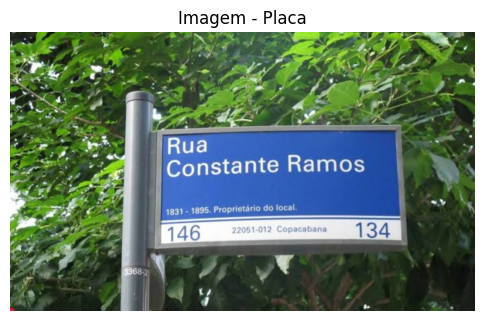

In [3]:
img = cv2.imread("Imagem 1/placa.jpg")

if img is None:
    print("Erro: imagem não encontrada.")
else:
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Imagem - Placa")
    plt.axis("off")
    plt.show()

===== SIFT =====
Quantidade de keypoints: 6018
Tempo de processamento: 2366.91 ms


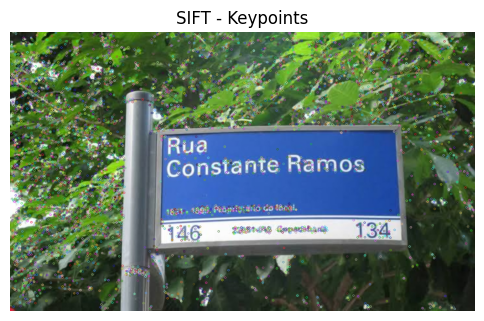

In [4]:
sift = cv2.SIFT_create()

start = time.time()
kp_sift, des_sift = sift.detectAndCompute(img_gray, None)
end = time.time()

tempo_sift = (end - start) * 1000

print("===== SIFT =====")
print("Quantidade de keypoints:", len(kp_sift))
print("Tempo de processamento: %.2f ms" % tempo_sift)

img_sift = cv2.drawKeypoints(img, kp_sift, None)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(img_sift, cv2.COLOR_BGR2RGB))
plt.title("SIFT - Keypoints")
plt.axis("off")
plt.show()

===== ORB =====
Quantidade de keypoints: 500
Tempo de processamento: 3931.79 ms


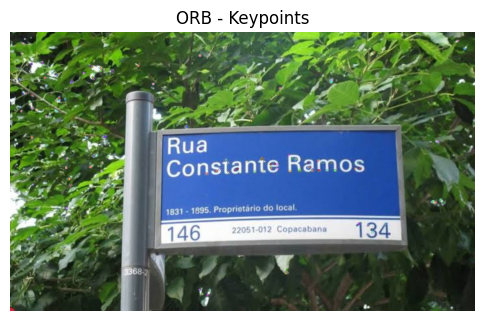

In [5]:
orb = cv2.ORB_create()

start = time.time()
kp_orb, des_orb = orb.detectAndCompute(img_gray, None)
end = time.time()

tempo_orb = (end - start) * 1000

print("===== ORB =====")
print("Quantidade de keypoints:", len(kp_orb))
print("Tempo de processamento: %.2f ms" % tempo_orb)

img_orb = cv2.drawKeypoints(img, kp_orb, None)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(img_orb, cv2.COLOR_BGR2RGB))
plt.title("ORB - Keypoints")
plt.axis("off")
plt.show()

===== HOG =====
Tamanho do vetor de características: 191520
Tempo de processamento: 3905.63 ms


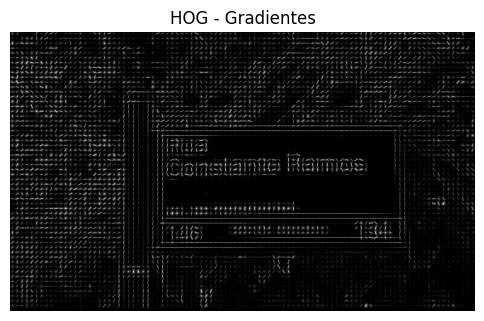

In [6]:
start = time.time()

hog_features, hog_image = hog(
    img_gray,
    pixels_per_cell=(16,16),
    cells_per_block=(2,2),
    visualize=True
)

end = time.time()

tempo_hog = (end - start) * 1000

print("===== HOG =====")
print("Tamanho do vetor de características:", len(hog_features))
print("Tempo de processamento: %.2f ms" % tempo_hog)

hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0,10))

plt.figure(figsize=(6,6))
plt.imshow(hog_image_rescaled, cmap="gray")
plt.title("HOG - Gradientes")
plt.axis("off")
plt.show()

In [7]:
dados = {
    "Método": ["SIFT", "ORB", "HOG"],
    "Keypoints / Dimensão": [
        len(kp_sift),
        len(kp_orb),
        len(hog_features)
    ],
    "Tempo (ms)": [
        tempo_sift,
        tempo_orb,
        tempo_hog
    ]
}

df = pd.DataFrame(dados)
df

,Método,Keypoints / Dimensão,Tempo (ms)
0,SIFT,6018,2366.906404
1,ORB,500,3931.787014
2,HOG,191520,3905.626297


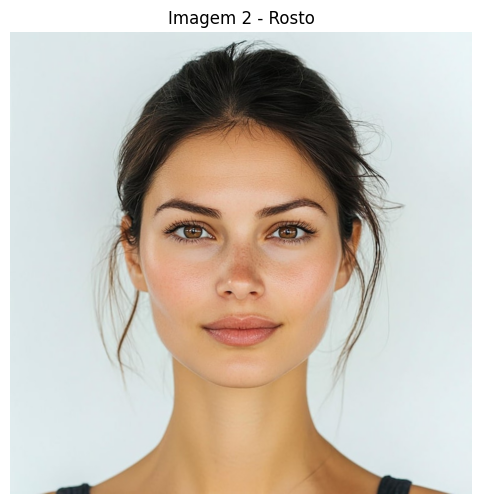

In [14]:
img2 = cv2.imread("Imagem 1/rosto.jpg")

if img2 is None:
    print("Erro: imagem não encontrada.")
else:
    img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
    plt.title("Imagem 2 - Rosto")
    plt.axis("off")
    plt.show()

===== SIFT - Rosto =====
Quantidade de keypoints: 2715
Tempo de processamento: 5611.02 ms


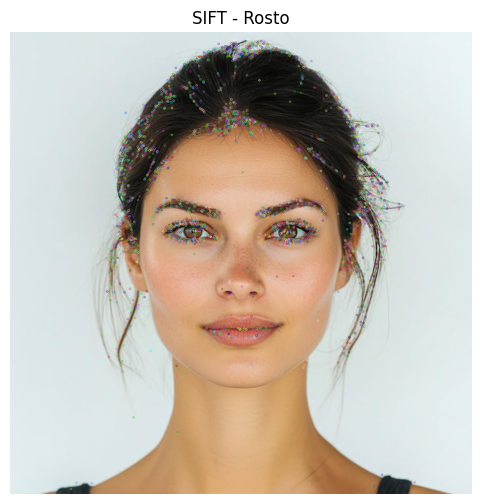

In [15]:
sift = cv2.SIFT_create()

start = time.time()
kp2_sift, des2_sift = sift.detectAndCompute(img2_gray, None)
end = time.time()

tempo2_sift = (end - start) * 1000

print("===== SIFT - Rosto =====")
print("Quantidade de keypoints:", len(kp2_sift))
print("Tempo de processamento: %.2f ms" % tempo2_sift)

img2_sift = cv2.drawKeypoints(img2, kp2_sift, None)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(img2_sift, cv2.COLOR_BGR2RGB))
plt.title("SIFT - Rosto")
plt.axis("off")
plt.show()

===== ORB - Rosto =====
Quantidade de keypoints: 500
Tempo de processamento: 1083.69 ms


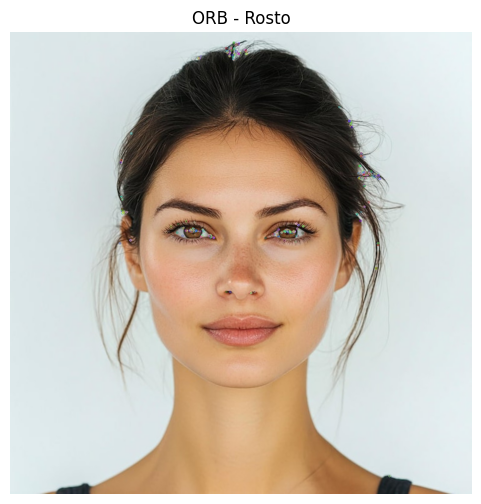

In [16]:
orb = cv2.ORB_create()

start = time.time()
kp2_orb, des2_orb = orb.detectAndCompute(img2_gray, None)
end = time.time()

tempo2_orb = (end - start) * 1000

print("===== ORB - Rosto =====")
print("Quantidade de keypoints:", len(kp2_orb))
print("Tempo de processamento: %.2f ms" % tempo2_orb)

img2_orb = cv2.drawKeypoints(img2, kp2_orb, None)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(img2_orb, cv2.COLOR_BGR2RGB))
plt.title("ORB - Rosto")
plt.axis("off")
plt.show()

===== HOG - Rosto =====
Tamanho do vetor: 324900
Tempo de processamento: 5625.89 ms


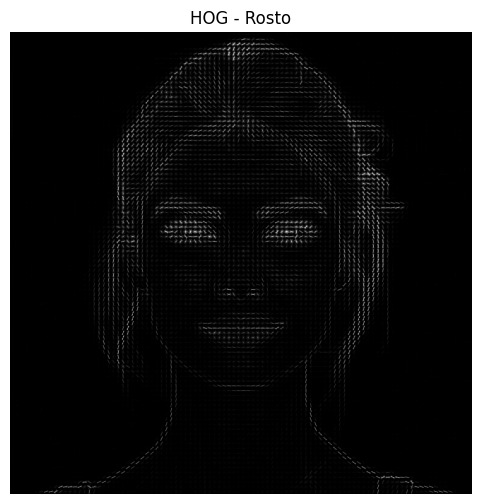

In [17]:
start = time.time()

hog2_features, hog2_image = hog(
    img2_gray,
    pixels_per_cell=(16,16),
    cells_per_block=(2,2),
    visualize=True
)

end = time.time()

tempo2_hog = (end - start) * 1000

print("===== HOG - Rosto =====")
print("Tamanho do vetor:", len(hog2_features))
print("Tempo de processamento: %.2f ms" % tempo2_hog)

hog2_image_rescaled = exposure.rescale_intensity(hog2_image, in_range=(0,10))

plt.figure(figsize=(6,6))
plt.imshow(hog2_image_rescaled, cmap="gray")
plt.title("HOG - Rosto")
plt.axis("off")
plt.show()

In [18]:
dados2 = {
    "Método": ["SIFT", "ORB", "HOG"],
    "Keypoints / Dimensão": [
        len(kp2_sift),
        len(kp2_orb),
        len(hog2_features)
    ],
    "Tempo (ms)": [
        tempo2_sift,
        tempo2_orb,
        tempo2_hog
    ]
}

df2 = pd.DataFrame(dados2)
df2

,Método,Keypoints / Dimensão,Tempo (ms)
0,SIFT,2715,5611.019373
1,ORB,500,1083.686829
2,HOG,324900,5625.891924
